In [1]:
import pandas as pd

data = {
    "Study_Hours": [2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                    2, 4, 6, 8, 10],
    "Attendance": [60, 65, 70, 75, 80, 85, 90, 92, 95, 98,
                   62, 72, 82, 88, 96],
    "Assignment_Score": [40, 45, 50, 55, 65, 70, 75, 80, 90, 95,
                         42, 52, 68, 78, 92],
    "Exam_Score": [45, 50, 55, 60, 68, 72, 78, 85, 92, 96,
                   48, 58, 70, 82, 94],
    "Sleep_Hours": [5, 6, 6, 7, 7, 8, 8, 8, 9, 9,
                    5, 6, 7, 8, 9]
}

df = pd.DataFrame(data)

print(df)

    Study_Hours  Attendance  Assignment_Score  Exam_Score  Sleep_Hours
0             2          60                40          45            5
1             3          65                45          50            6
2             4          70                50          55            6
3             5          75                55          60            7
4             6          80                65          68            7
5             7          85                70          72            8
6             8          90                75          78            8
7             9          92                80          85            8
8            10          95                90          92            9
9            11          98                95          96            9
10            2          62                42          48            5
11            4          72                52          58            6
12            6          82                68          70            7
13    

In [5]:
X = df[
    ["Study_Hours", "Attendance", "Assignment_Score",
     "Exam_Score", "Sleep_Hours"]
]


In [21]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [7]:
df.describe()

,Study_Hours,Attendance,Assignment_Score,Exam_Score,Sleep_Hours
count,15.000000,15.000000,15.000000,15.000000,15.000000
mean,6.333333,80.666667,66.466667,70.200000,7.200000
std,2.968084,12.742878,18.512030,17.226226,1.373213
min,2.000000,60.000000,40.000000,45.000000,5.000000
25%,4.000000,71.000000,51.000000,56.500000,6.000000
50%,6.000000,82.000000,68.000000,70.000000,7.000000
75%,8.500000,91.000000,79.000000,83.500000,8.000000
max,11.000000,98.000000,95.000000,96.000000,9.000000


In [11]:
scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)
pd.DataFrame(x_scaled).head()

,0,1,2,3,4
0,-1.511219,-1.678744,-1.479881,-1.514231,-1.658312
1,-1.162476,-1.272596,-1.200307,-1.213788,-0.904534
2,-0.813733,-0.866449,-0.920732,-0.913345,-0.904534
3,-0.464991,-0.460301,-0.641158,-0.612903,-0.150756
4,-0.116248,-0.054153,-0.082009,-0.132195,-0.150756


In [12]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(x_scaled)

In [13]:
print( X.shape)
print( X_pca.shape)

(15, 5)
(15, 2)


In [14]:
pca_df = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

pca_df.head()

,PC1,PC2
0,-3.506708,-0.147512
1,-2.574155,0.239096
2,-1.975984,-0.005457
3,-1.043431,0.381151
4,-0.239246,-0.033825


In [17]:
print(pca.explained_variance_ratio_)

[0.98901305 0.00736905]


In [18]:
for i, variance in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {variance*100:.2f}%")

PC1: 98.90%
PC2: 0.74%


In [22]:
print("Total Variance Retained:",
      np.sum(pca.explained_variance_ratio_))

Total Variance Retained: 0.9963820944522068


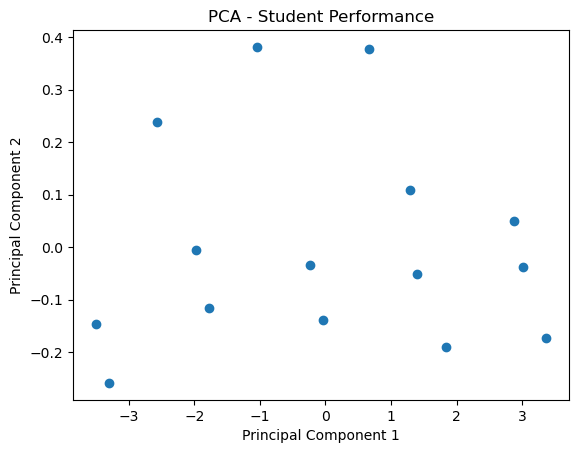

In [25]:
plt.scatter(pca_df["PC1"], pca_df["PC2"])

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Student Performance")

plt.show()